# Part 8 — Evaluation and backtesting: skill or luck?

**Analogy.** A student who memorised last year's exam scores 100% on last year's exam. You
only learn whether they understand the subject by giving them **a new exam**, several new exams
in fact, and checking that the score isn't a fluke.

Everything so far produced *one* test-period number per agent. By now you've seen how fragile
that is: seeds change results, train looks far better than test, and one strategy can look
brilliant for six years by luck. This part is the toolkit that stands between you and fooling
yourself:

| § | Tool | Question it answers |
|---|---|---|
| 8.1 | Baselines | "Better than *what*?" |
| 8.2 | Walk-forward evaluation | "Would it have worked, retrained the way I'd really retrain it?" |
| 8.3 | A metrics scorecard | "Better on which dimension: return, risk, costs, tails?" |
| 8.4 | Block bootstrap | "Is the edge statistically real, or noise?" |
| 8.5 | Multiple-testing check | "I tried 30 configs. Is the best one just the luckiest?" |
| 8.6 | Many simulated worlds | "Does the *method* work, or did it just fit *this* history?" |
| 8.7 | Stress tests | "What if costs double, or the vol premium shrinks?" |
| 8.8 | Diagnostics plots | "Is it doing what I think it's doing?" |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, os
import optrl
from optrl import metrics as M
M.set_style()
A = optrl.ACTION_NAMES
F = optrl.MarketData.FEATURES
market = optrl.load_default_market()
df = market.df

### The agents we'll evaluate
To keep this notebook self-contained and fast, we reuse two agents from earlier parts as
compact functions: the **tabular Q-learner** (Part 5), which is cheap to retrain many times, and
the **online ridge selector** (Part 3), deployed into the carry-over environment. The same
procedures apply unchanged to DQN/PPO. They just take longer.

In [2]:
def train_q(market_, episodes=1500, gamma=0.9, alpha=0.05, seed=0, env_kwargs=None):
    env = optrl.DiscretizeObs(optrl.OptionsSelectionEnv(market_, seed=seed, **(env_kwargs or {})))
    Q = np.zeros((env.observation_space.n, 8)); rng = np.random.default_rng(seed)
    for ep in range(episodes):
        eps = max(0.05, 1 - ep / (0.7 * episodes))
        s, _ = env.reset(); done = False
        while not done:
            a = int(rng.integers(8)) if rng.random() < eps else int(Q[s].argmax())
            s2, r, te, tr, _ = env.step(a); done = te or tr
            Q[s, a] += alpha * (r + (0 if te else gamma * Q[s2].max()) - Q[s, a]); s = s2
    return Q

def q_policy(Q, market_):
    bk = optrl.DiscretizeObs.market_buckets(market_.df)
    return lambda obs, env: int(Q[bk[env.i] * 8 + int(np.argmax(obs[len(F):len(F) + 8]))].argmax())

def ridge_policy(train_market, lam=1.0):
    """Contextual-bandit selector: ridge on the weekly P&L table (full info), acts greedily."""
    tb = optrl.weekly_pnl_table(train_market); Xtr = optrl.decision_features(train_market, tb)
    mu, sd = Xtr.mean().values, Xtr.std().values
    Z = np.c_[np.ones(len(Xtr)), np.clip((Xtr.values - mu) / sd, -5, 5)]
    W = np.linalg.solve(Z.T @ Z + lam * np.eye(Z.shape[1]), Z.T @ (tb.values / 1000))
    def act(obs, env):
        x = np.r_[1.0, np.clip((env.df[F].iloc[env.i].values - mu) / sd, -5, 5)]
        return int(np.argmax(x @ W))
    return act

def rollout(mkt, policy, stats, **kw):
    return M.full_period_rollout(optrl.OptionsSelectionEnv, mkt, policy, obs_stats=stats, **kw)

---
## 8.1 Baselines: always ask "better than what?"

| Baseline | Why include it |
|---|---|
| `no_trade` | P&L floor. Does the agent even beat cash? |
| each **single strategy**, always on | the obvious alternative to a selector |
| **best single strategy picked on the training data** | what a non-RL researcher would deploy |
| **random** selector | any agent must crush this |
| a **hand-written rule** (Part 1's term-structure rule) | "does RL beat 2 lines of trader logic?" |
| an **oracle** that sees the hidden regime | an upper bound: how much is left on the table? |

The rule-based baseline is the most important and the most often skipped. If RL can't beat a
sensible two-line rule, it isn't worth its complexity.

In [3]:
train, test = market.split(0.7)
stats = (train.df[F].mean().values, train.df[F].std().values)
tbl_train = optrl.weekly_pnl_table(train)
best_single = int(tbl_train.mean().values.argmax())
oracle_map = tbl_train.groupby(train.df.loc[tbl_train.index, "regime_name"]).mean().idxmax(axis=1)
TS_i = F.index("term_structure")
rng = np.random.default_rng(0)

baselines = {
    "no_trade": lambda o, e: 0,
    f"best single on train ({A[best_single]})": lambda o, e: best_single,
    "random": lambda o, e: int(rng.integers(8)),
    "rule: backwardation→bear put, else bull put": lambda o, e: 7 if e.df.term_structure.iloc[e.i] > 1.0 else 3,
    "oracle (sees hidden regime)": lambda o, e: A.index(oracle_map[e.df.regime_name.iloc[e.i]]),
}
t0 = time.time()
Q_single = train_q(train)
agents = {"Q-learning": q_policy(Q_single, test), "ridge selector": ridge_policy(train)}
runs = {k: rollout(test, p, stats) for k, p in {**agents, **baselines}.items()}
print(f"({time.time() - t0:.0f}s)")
score = pd.DataFrame({k: M.summarize(v.pnl.values) for k, v in runs.items()}).T
score["cost $/wk"] = [v.cost.mean() for v in runs.values()]
score.round(2)

(10s)


,total_pnl,mean_per_period,sharpe,max_drawdown,cvar_5%,win_rate,cost $/wk
Q-learning,6974.80,23.33,0.51,2877.17,-780.14,0.69,20.02
ridge selector,17595.55,58.85,0.83,3196.71,-940.56,0.63,31.50
no_trade,0.00,0.00,0.00,0.00,0.00,NaN,0.00
best single on train (bull_put_spread),5559.95,18.60,0.59,2646.12,-716.94,0.75,7.89
random,-11521.26,-38.53,-0.65,13041.28,-878.22,0.44,52.23
"rule: backwardation→bear put, else bull put",10951.68,36.63,0.68,4716.64,-990.88,0.76,15.05
oracle (sees hidden regime),26050.69,87.13,1.28,5790.96,-961.17,0.72,19.92


---
## 8.2 Walk-forward evaluation

A single train/test split answers "how would a model trained on 2006–2019 have done in
2019–2025?". But you wouldn't trade one frozen model for six years. You'd **retrain
periodically**. Walk-forward simulates exactly that:

```
fold 1: train [2006 ─────── 2013]  test [2014]
fold 2: train [2006 ──────── 2014]  test [2015]
fold 3: train [2006 ───────── 2015]  test [2016]   ... and so on
```

Stitch the test years together and you get one long **out-of-sample** equity curve made of
genuinely unseen data. Each fold also gives a separate data point on performance, which is far
more informative than one number.

**A subtle leak to avoid.** Positions opened at the end of a training window expire *inside* the
test window. We leave a small **gap** (the option life, 10 days) between train and test so no
training label depends on test-period prices.

In [4]:
def walk_forward(first_test_year=2014, last_year=2025, gap_days=10, episodes=1500):
    years = df.index.year
    out = []
    for y in range(first_test_year, last_year + 1):
        tr_idx = np.flatnonzero(years < y)[:-gap_days]
        te_idx = np.flatnonzero(years == y)
        if len(te_idx) < 60:
            continue
        tr_m = optrl.MarketData(df.iloc[tr_idx].copy()); te_m = optrl.MarketData(df.iloc[te_idx].copy())
        st = (tr_m.df[F].mean().values, tr_m.df[F].std().values)
        pols = {"Q-learning": q_policy(train_q(tr_m, episodes=episodes, seed=y), te_m),
                "ridge selector": ridge_policy(tr_m),
                "best single on train": (lambda b: (lambda o, e: b))(int(optrl.weekly_pnl_table(tr_m).mean().values.argmax())),
                "rule": lambda o, e: 7 if e.df.term_structure.iloc[e.i] > 1.0 else 3,
                "always short_straddle": lambda o, e: 1}
        for name, p in pols.items():
            r = rollout(te_m, p, st); r["fold"] = y; r["agent"] = name
            out.append(r)
    return pd.concat(out, ignore_index=True)

t0 = time.time()
wf = walk_forward()
print(f"walk-forward done in {time.time() - t0:.0f}s, {wf.fold.nunique()} yearly folds")
by_year = wf.pivot_table(index="fold", columns="agent", values="pnl", aggfunc="sum")
by_year.round(0)

walk-forward done in 118s, 12 yearly folds


agent,Q-learning,always short_straddle,best single on train,ridge selector,rule
fold,,,,,
2014,2776.0,1216.0,899.0,229.0,899.0
2015,1425.0,-988.0,-497.0,2008.0,1368.0
2016,2056.0,1770.0,2302.0,1208.0,2302.0
2017,7219.0,-183.0,1589.0,1145.0,-444.0
2018,-3478.0,-2813.0,-3193.0,3854.0,7329.0
2019,9502.0,2210.0,4356.0,11724.0,4356.0
2020,-2479.0,-184.0,1020.0,4959.0,-91.0
2021,3796.0,-152.0,-173.0,5459.0,-2241.0
2022,-2627.0,2555.0,1852.0,-331.0,6099.0


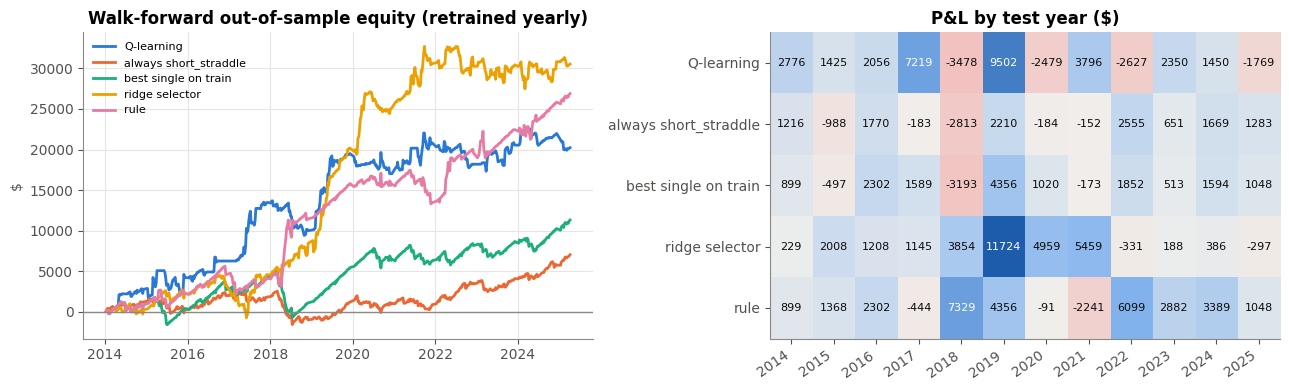

share of years each agent beat 'best single on train':
 agent
Q-learning               0.50
always short_straddle    0.58
ridge selector           0.42
rule                     0.42


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, a in enumerate(by_year.columns):
    s = wf[wf.agent == a].set_index("date").pnl
    axes[0].plot(s.index, s.cumsum(), label=a, color=M.PALETTE[i])
axes[0].axhline(0, color="#8a8983", lw=1); axes[0].set_title("Walk-forward out-of-sample equity (retrained yearly)")
axes[0].legend(fontsize=8); axes[0].set_ylabel("$")
M.plot_value_heatmap(by_year.T, "P&L by test year ($)", ax=axes[1])
plt.tight_layout(); plt.show()
wins = (by_year.drop(columns="best single on train").gt(by_year["best single on train"], axis=0)).mean()
print("share of years each agent beat 'best single on train':\n", wins.round(2).to_string())

**How to read a walk-forward result.**
* The yearly heatmap tells you *when* each method makes and loses money. Losses concentrated in
  one or two crisis years is a very different risk profile from a slow bleed.
* "Share of years beating the benchmark" is a robust, intuitive statistic. Above ~60–70% over
  10+ folds starts to look like skill. Around 50% is a coin flip.

---
## 8.3 The metrics scorecard

| Metric | Meaning | Worked example |
|---|---|---|
| mean \$/week | average weekly P&L | \$40/wk ≈ \$2,080/yr on \$1,000 risk per trade |
| **Sharpe** (annualised) | mean / std × √52 | mean 40, std 300 → 40/300·7.21 = **0.96** |
| **max drawdown** | worst peak-to-trough fall of cumulative P&L | peak \$12k → trough \$7k = **\$5k** |
| **CVaR 5%** | average of the worst 5% of weeks | "in a bad week (1 in 20) expect −\$900" |
| win rate | share of trading weeks with P&L > 0 | short premium: high win rate, fat left tail |
| cost \$/wk | commissions + spread paid | the silent killer of high-turnover agents |

No single metric is enough. A short straddle has a lovely win rate and Sharpe right up until
the week it doesn't. That's why CVaR and max drawdown sit next to Sharpe.

In [6]:
card = {}
for a in by_year.columns:
    r = wf[wf.agent == a]
    s = M.summarize(r.pnl.values); s["cost $/wk"] = r.cost.mean()
    card[a] = s
card = pd.DataFrame(card).T
print("Walk-forward scorecard (all out-of-sample folds stitched together):")
card.round(2)

Walk-forward scorecard (all out-of-sample folds stitched together):


,total_pnl,mean_per_period,sharpe,max_drawdown,cvar_5%,win_rate,cost $/wk
Q-learning,20220.32,37.24,0.61,4722.63,-894.76,0.60,24.59
always short_straddle,7032.79,12.95,0.48,4140.69,-543.34,0.66,7.09
best single on train,11310.24,20.83,0.66,5695.32,-659.86,0.75,8.06
ridge selector,30533.13,56.23,0.88,5254.33,-963.57,0.67,28.23
rule,26895.75,49.53,0.98,4149.02,-885.14,0.75,13.41


---
## 8.4 Is the edge real? The block bootstrap

The Q-learner beat the benchmark in the table above, but by how much *relative to the noise*?

**Idea.** Resample the out-of-sample weeks many times to create thousands of alternative
histories, and see how often the agent still wins. We resample **blocks** of consecutive weeks
(e.g. 8), not single weeks, because P&L is autocorrelated. Regimes last for weeks, and
shuffling individual weeks would destroy that and make results look more certain than they are.

We resample the **difference** in weekly P&L (agent − benchmark, same weeks), which cancels the
market noise both share. That's a *paired* test.

**Worked example of the output.** "Mean difference +\$18/week, 90% CI [−\$6, +\$41], agent
better in 88% of resamples." That means a probable edge, but a zero edge isn't ruled out.

### 🛠 Exercise 8.4: implement a circular block bootstrap
Write `block_bootstrap(x, block=8, n_boot=5000)` returning an array of resampled **means** of
x. Circular: blocks that run past the end wrap around to the start.

In [7]:
def block_bootstrap(x, block=8, n_boot=5000, seed=0):
    # TODO
    return None

**Solution**

In [8]:
def block_bootstrap(x, block=8, n_boot=5000, seed=0, stat=np.mean):
    x = np.asarray(x, float); n = len(x); rng = np.random.default_rng(seed)
    n_blocks = int(np.ceil(n / block))
    starts = rng.integers(0, n, (n_boot, n_blocks))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]).reshape(n_boot, -1)[:, :n] % n
    return np.array([stat(x[i]) for i in idx])

def compare(agent, bench, block=8):
    a = wf[wf.agent == agent].pnl.values; b = wf[wf.agent == bench].pnl.values
    diff = a - b
    boot = block_bootstrap(diff, block)
    lo, hi = np.percentile(boot, [5, 95])
    return {"mean diff $/wk": diff.mean(), "90% CI low": lo, "90% CI high": hi, "P(agent better)": (boot > 0).mean()}

tests = pd.DataFrame({f"{a} vs {b}": compare(a, b) for a, b in [
    ("Q-learning", "best single on train"), ("ridge selector", "best single on train"),
    ("Q-learning", "rule"), ("Q-learning", "ridge selector")]}).T
tests.round(3)

,mean diff $/wk,90% CI low,90% CI high,P(agent better)
Q-learning vs best single on train,16.409,-16.282,49.145,0.794
ridge selector vs best single on train,35.401,-1.643,72.842,0.942
Q-learning vs rule,-12.294,-50.949,27.560,0.307
Q-learning vs ridge selector,-18.992,-56.181,17.502,0.197


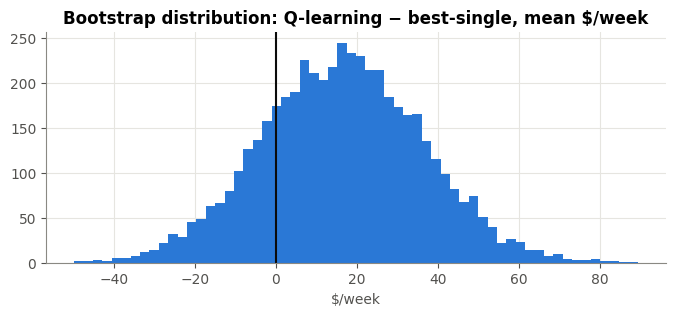

In [9]:
boot = block_bootstrap(wf[wf.agent == "Q-learning"].pnl.values - wf[wf.agent == "best single on train"].pnl.values)
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(boot, bins=60, color=M.PALETTE[0]); ax.axvline(0, color="#0b0b0b", lw=1.5)
ax.set_title("Bootstrap distribution: Q-learning − best-single, mean $/week"); ax.set_xlabel("$/week"); plt.show()

---
## 8.5 The multiple-testing trap

Suppose you tried 30 configurations (γ, α, features, reward λ, network sizes…) and report the
best test Sharpe. Even if **none** has any skill, the best of 30 will look good by luck.

**Demonstration.** Create 30 "strategies" with **zero true edge**: bootstrapped copies of the
agent's weekly P&L with the mean subtracted, so their true Sharpe is exactly 0. Look at the best
Sharpe among them.

Best Sharpe among 30 ZERO-EDGE strategies: median 0.56, 90th pct 0.75
Our Q-learning walk-forward Sharpe: 0.61


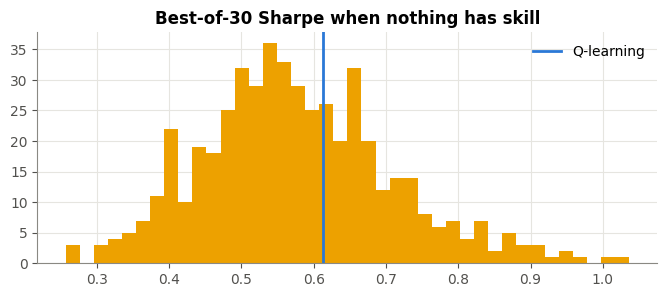

In [10]:
x = wf[wf.agent == "Q-learning"].pnl.values
x0 = x - x.mean()                                       # true edge = 0
null_best = []
for k in range(500):
    sharpes = block_bootstrap(x0, 8, 30, seed=k, stat=M.sharpe)
    null_best.append(sharpes.max())
null_best = np.array(null_best)
print(f"Best Sharpe among 30 ZERO-EDGE strategies: median {np.median(null_best):.2f}, 90th pct {np.percentile(null_best, 90):.2f}")
print(f"Our Q-learning walk-forward Sharpe: {M.sharpe(x):.2f}")
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(null_best, bins=40, color=M.PALETTE[3]); ax.axvline(M.sharpe(x), color=M.PALETTE[0], lw=2, label="Q-learning")
ax.set_title("Best-of-30 Sharpe when nothing has skill"); ax.legend(); plt.show()

**Rule of thumb.** The more things you try, the higher the bar. Keep a **log of every
experiment** (Part 9), report how many you ran, and compare your best result against the
best-of-N null above. That's the idea behind the "deflated Sharpe ratio" used by quant
researchers. Better still, **touch the final test period once**, at the very end.

---
## 8.6 Many simulated worlds: does the *method* work?

Real data gives you one history. The simulator gives you as many as you like. Rerun the whole
pipeline (train on 70%, test on 30%) in several independent worlds. If the method only wins in
the world you developed it on, it fitted that world, not the problem.

In [11]:
def one_world(seed):
    m = optrl.simulate_market(seed=seed); tr, te = m.split(0.7)
    st = (tr.df[F].mean().values, tr.df[F].std().values)
    b = int(optrl.weekly_pnl_table(tr).mean().values.argmax())
    res = {}
    for name, p in {"Q-learning": q_policy(train_q(tr, seed=seed), te), "ridge selector": ridge_policy(tr),
                    "best single on train": lambda o, e: b}.items():
        res[name] = M.sharpe(rollout(te, p, st).pnl)
    return res

t0 = time.time()
worlds = pd.DataFrame({s: one_world(s) for s in range(100, 106)}).T
print(f"({time.time() - t0:.0f}s)"); print(worlds.round(2).to_string())
print("\nQ-learning beats best-single in", (worlds["Q-learning"] > worlds["best single on train"]).sum(), "of", len(worlds), "worlds;",
      "ridge in", (worlds["ridge selector"] > worlds["best single on train"]).sum())

(60s)
     Q-learning  ridge selector  best single on train
100        0.93            0.92                  0.70
101        0.14            0.93                  1.47
102        0.69            0.50                  0.65
103        1.07            0.38                  0.51
104        0.86            0.57                  1.18
105        0.78            0.62                  0.93

Q-learning beats best-single in 3 of 6 worlds; ridge in 1


---
## 8.7 Stress tests

A strategy selector that only works under the exact assumptions it was trained on is fragile.
Keep the trained policy **fixed** and change the world:
* **Costs ×2 and ×3**: wider spreads in a real crisis, or a worse broker.
* **Vol premium compression**: implied vol only 15% above realised in calm markets instead of 35%.
  Premium selling pays less, which happens when everyone crowds into the same trade.

In [12]:
stress = {}
for label, kw in [("base", {}), ("costs ×2", {"cost_multiplier": 2.0}), ("costs ×3", {"cost_multiplier": 3.0})]:
    stress[label] = {n: rollout(test, p, stats, **kw).pnl.mean() for n, p in
                     {"Q-learning": agents["Q-learning"], "ridge selector": agents["ridge selector"],
                      "always short_straddle": lambda o, e: 1}.items()}

rp = {k: dict(v) for k, v in optrl.REGIME_PARAMS.items()}
rp["calm_bull"]["iv_prem"] = 1.15; rp["range"]["iv_prem"] = 1.15
compressed = optrl.simulate_market(n_days=252 * 20, seed=optrl.DEFAULT_SEED, regime_params=rp)
_, test_c = compressed.split(0.7)
stress["vol premium compressed"] = {n: rollout(test_c, p, stats).pnl.mean() for n, p in
                                    {"Q-learning": q_policy(Q_single, test_c), "ridge selector": agents["ridge selector"],
                                     "always short_straddle": lambda o, e: 1}.items()}
pd.DataFrame(stress).round(1)

,base,costs ×2,costs ×3,vol premium compressed
Q-learning,23.3,3.3,-16.7,21.4
ridge selector,58.8,27.4,-4.1,76.7
always short_straddle,26.6,19.6,12.5,12.4


Two things to look for. (1) **High-turnover agents degrade fastest as costs rise.** If a
doubling of costs wipes out the edge, the edge was mostly "trading the spread". (2) When the vol
premium shrinks, **all** short-premium approaches suffer. Does the agent at least lose less than
the always-short baseline, by shifting to other strategies?

---
### The verdict on our agents (read this carefully)
Put the evidence from 8.1–8.7 together, as you would in a research review:

1. **Over 12 walk-forward years, the ridge selector and the two-line rule have the best
   risk-adjusted results.** The tabular Q-learner is middling: better than the always-on
   strategies on average P&L, but not on Sharpe.
2. **No method beats the best-single benchmark in a clear majority of years** (all around
   40–60%). The edges are modest compared with year-to-year noise.
3. **The bootstrap** gives the ridge selector's edge over best-single roughly a 94% probability,
   the most convincing result. Q-learning's ≈ 79% is suggestive at best.
4. **Best-of-N:** Q-learning's walk-forward Sharpe (≈ 0.6) sits right in the range that the
   best of 30 zero-skill strategies reaches by luck. If we had tuned 30 variants and reported the
   best, we couldn't call it skill.
5. **Across simulated worlds** no method wins everywhere. Q-learning beats best-single in about
   half of them.
6. **Costs:** at 2× costs the Q-learner's edge all but vanishes and the ridge selector's is
   roughly halved, while the low-turnover, always-on short straddle degrades gracefully.

**This is what honest RL research on trading looks like.** It isn't a failure. It's the process
working. Without these tools you'd have deployed the DQN from Part 7a with its in-sample Sharpe
of 3.5. The next step is to *improve the agent in a disciplined way* (Part 9), and to take seriously
the possibility that a simple, well-built contextual bandit, or even a good rule, is the right
answer for your data.

---
## 8.8 Diagnostics: is it doing what I think it's doing?

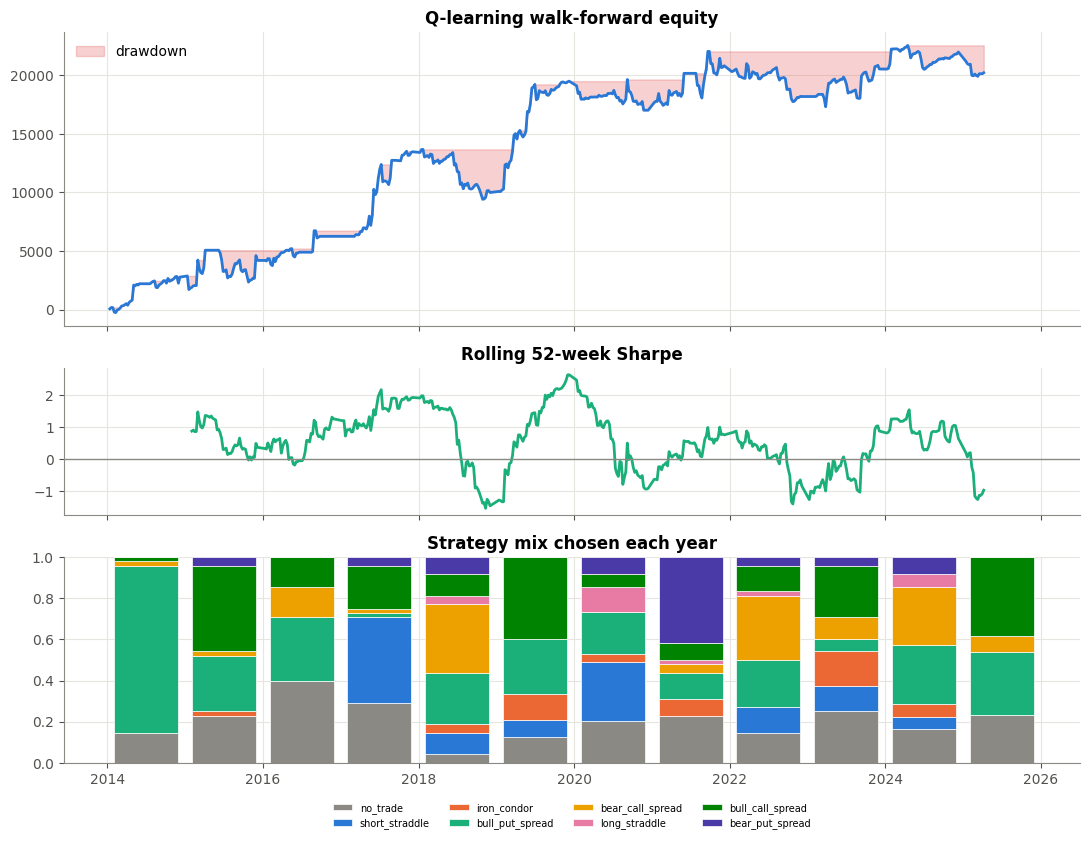

In [13]:
q_oos = wf[wf.agent == "Q-learning"].set_index("date")
fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1.4]})
eq = q_oos.pnl.cumsum(); dd = eq - eq.cummax()
axes[0].plot(eq.index, eq, color=M.PALETTE[0]); axes[0].set_title("Q-learning walk-forward equity")
axes[0].fill_between(dd.index, eq.cummax(), eq, color=M.PALETTE[7], alpha=0.25, label="drawdown"); axes[0].legend()
roll = q_oos.pnl.rolling(52).apply(lambda s: M.sharpe(s))
axes[1].plot(roll.index, roll, color=M.PALETTE[2]); axes[1].axhline(0, color="#8a8983", lw=1); axes[1].set_title("Rolling 52-week Sharpe")
mix = pd.crosstab(q_oos.index.year, q_oos.action, normalize="index").reindex(columns=A, fill_value=0)
bottom = np.zeros(len(mix))
for a in A:
    axes[2].bar(pd.to_datetime([f"{y}-07-01" for y in mix.index]), mix[a], bottom=bottom, width=300,
                color=M.ACTION_COLORS[a], label=a, edgecolor="white", linewidth=0.5)
    bottom += mix[a].values
axes[2].set_title("Strategy mix chosen each year"); axes[2].legend(ncol=4, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout(); plt.show()

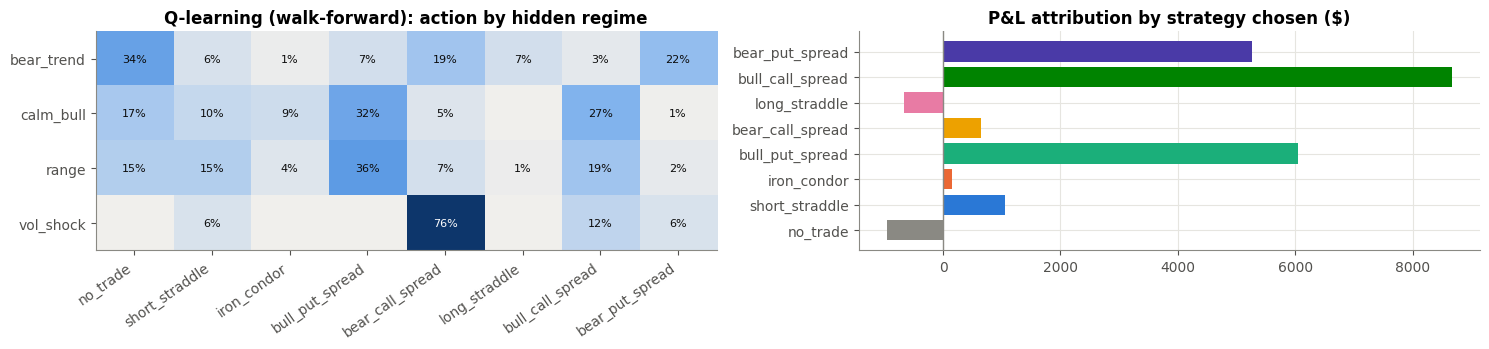

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3.6))
M.plot_selection_heatmap(q_oos, row="regime", ax=axes[0], title="Q-learning (walk-forward): action by hidden regime")
contrib = q_oos.groupby("action").pnl.sum().reindex(A).fillna(0)
axes[1].barh(contrib.index, contrib.values, color=[M.ACTION_COLORS[a] for a in contrib.index])
axes[1].axvline(0, color="#8a8983", lw=1); axes[1].set_title("P&L attribution by strategy chosen ($)")
plt.tight_layout(); plt.show()

**Checklist for the diagnostics.**
* Equity + drawdown: are losses concentrated or spread out? How long are the underwater periods?
* Rolling Sharpe: is performance **decaying** over time? That's a sign the market drifted away
  from the training data.
* Strategy mix by year: does behaviour change sensibly with the market, or is it stuck on one
  strategy?
* Selection by regime: does it line up with what should work (Part 0's heatmap)?
* P&L attribution: is the profit coming from one strategy, and is that strategy's profit
  concentrated in a few weeks?

### 🛠 Exercise 8.8: the "too good to be true" audit
A colleague reports a walk-forward Sharpe of 4.0 for their selector. List five checks from this
notebook you'd run before believing it, and implement the fastest one on our Q-learner: the
**train-vs-test gap**, meaning the Sharpe on the training period of the final fold vs its
out-of-sample Sharpe.

*Expected:* the training-period Sharpe is much higher than out-of-sample. A large gap is the
classic overfitting signature. (Five checks: look-ahead/truncation test, costs included and
stressed, bootstrap CI, best-of-N correction for the configs tried, performance across seeds
and simulated worlds, and the train/test gap.)

In [15]:
# TODO

**Solution**

In [16]:
last = df.index.year.max()
tr_m = optrl.MarketData(df[df.index.year < last].iloc[:-10].copy())
st = (tr_m.df[F].mean().values, tr_m.df[F].std().values)
Q_last = train_q(tr_m, seed=int(last))
in_sample = rollout(tr_m, q_policy(Q_last, tr_m), st)
print(f"final fold: training-period Sharpe {M.sharpe(in_sample.pnl):.2f}  vs  walk-forward OOS Sharpe {M.sharpe(q_oos.pnl):.2f}")

final fold: training-period Sharpe 1.41  vs  walk-forward OOS Sharpe 0.61


## Recap
* Always compare against **baselines**, especially a simple rule and the best single strategy.
* **Walk-forward** with a gap = realistic retraining, genuinely out-of-sample.
* Look at a **scorecard** (Sharpe, drawdown, CVaR, costs), never one number.
* Use a **paired block bootstrap** for confidence intervals. Beware **best-of-N** luck.
* Test the *method* across **simulated worlds** and **stress** the costs and market assumptions.
* Read the **diagnostics** to make sure the agent is right for the right reasons.

**Next → Part 9:** bring your own data and strategies, and run the improvement loop.